# Lab 5: Canny Edge Detection and Template Matching in OpenCV
This lab focuses on implementing Canny edge detection and template matching using OpenCV. The exercises cover detecting edges in an image and matching a template to locate an object. Code is designed for a Jupyter Notebook, with images displayed inline using matplotlib.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Exercise 1: Canny Edge Detection
Task: Apply Canny edge detection to an image and visualize the edges.

(-0.5, 799.5, 449.5, -0.5)

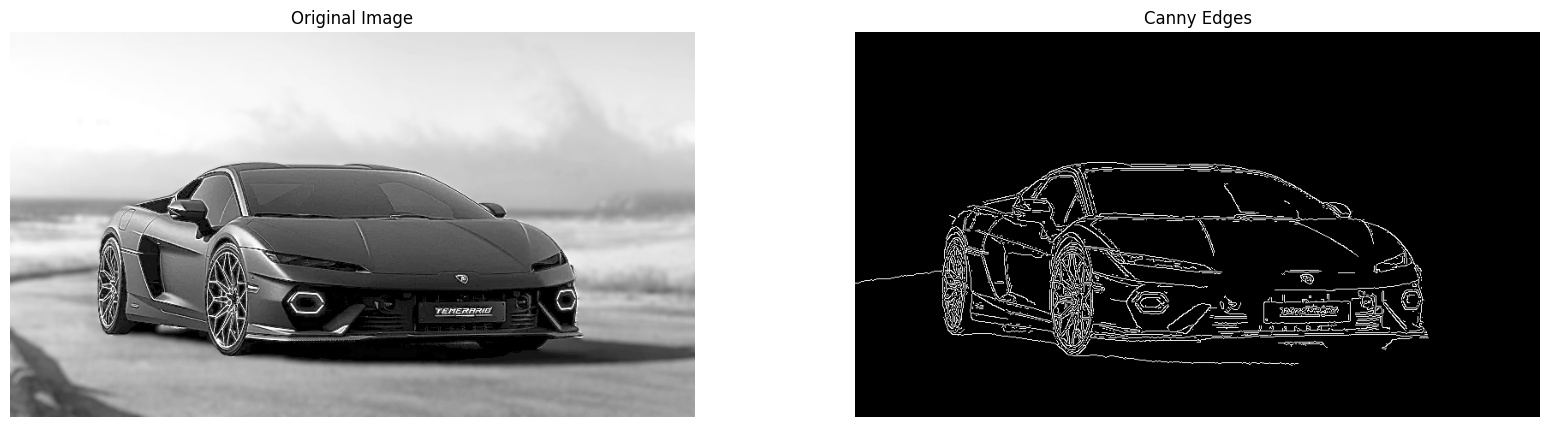

In [2]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Apply Canny edge detection
edges = cv2.Canny(img, threshold1=100, threshold2=200)

# Display images
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Canny Edges')
plt.imshow(edges, cmap='gray')
plt.axis('off')

## Exercise 2: Template Matching
Task: Use template matching to locate a small region (e.g., a car wheel) in the image.

(-0.5, 70.5, 52.5, -0.5)

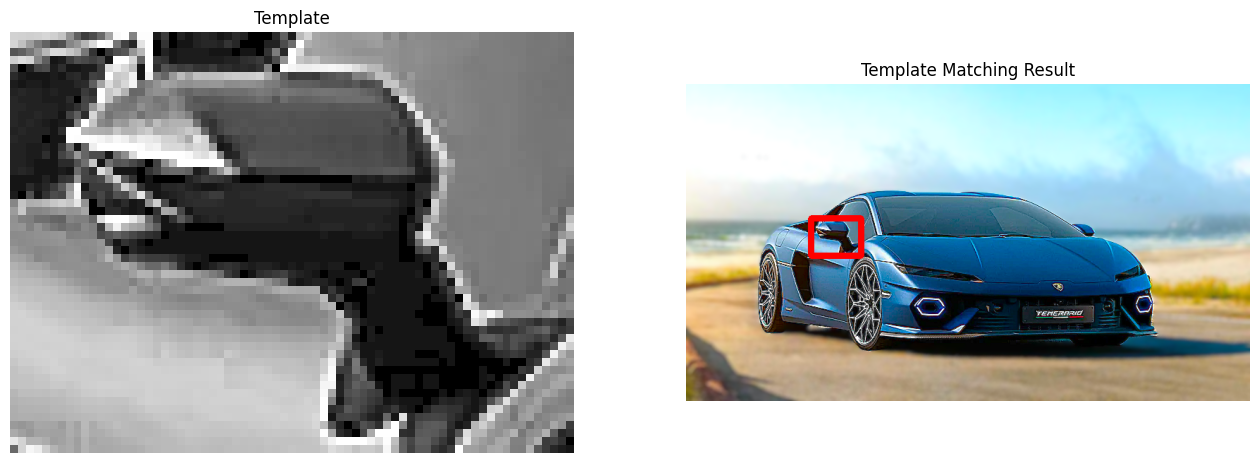

In [3]:
# Load image and template
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png')
if img is None:
    print("Error: Image not found.")
    exit()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
template = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car mirror.png', cv2.IMREAD_GRAYSCALE)
if template is None:
    print("Error: Template not found.")
    exit()

# Convert image to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Perform template matching
result = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

# Get template dimensions
w, h = template.shape[::-1]

# Draw rectangle around matched region
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)
cv2.rectangle(img_rgb, top_left, bottom_right, (255, 0, 0), 8)

# Display result
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 2)
plt.title('Template Matching Result')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 1)
plt.title('Template')
plt.imshow(template,cmap='gray')
plt.axis('off')


## Exercise 3: Combining Canny and Template Matching
Task: Apply Canny edge detection to both the image and template, then perform template matching.

(-0.5, 799.5, 449.5, -0.5)

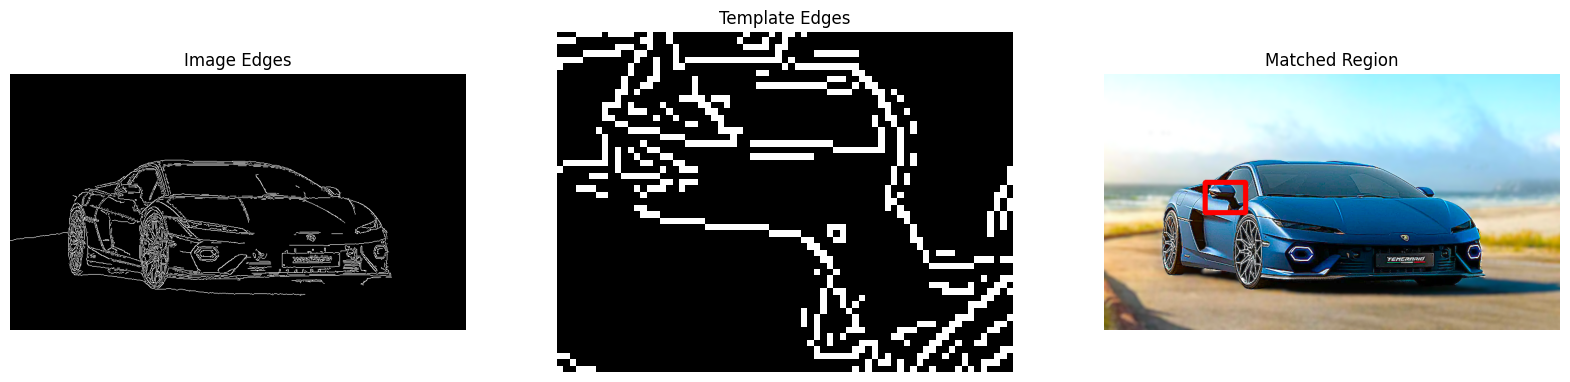

In [4]:
# Load image and template in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
template = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car mirror.png', cv2.IMREAD_GRAYSCALE)
if img is None or template is None:
    print("Error: Image or template not found.")
    exit()

# Apply Canny edge detection
img_edges = cv2.Canny(img, 100, 200)
template_edges = cv2.Canny(template, 100, 200)

# Perform template matching on edge images
result = cv2.matchTemplate(img_edges, template_edges, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

# Draw rectangle on original color image
img_rgb = cv2.cvtColor(cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png'), cv2.COLOR_BGR2RGB)
w, h = template.shape[::-1]
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)
cv2.rectangle(img_rgb, top_left, bottom_right, (255, 0, 0), 8)

# Display results
plt.figure(figsize=(20, 14))

plt.subplot(1, 3, 1)
plt.title('Image Edges')
plt.imshow(img_edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Template Edges')
plt.imshow(template_edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Matched Region')
plt.imshow(img_rgb)
plt.axis('off')

# By **Saddam Umer**

BS AI, SMIU